<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.10}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Alumna:} & Morales Ramirez Mariagne Quetzaltzin \\[6pt]
\textbf{Fecha de realización:} & 29/04/2026
\end{array}

</center>

***
**UNAM no guarda relación alguna con las marcas mencionadas como ejemplo. Las marcas son propiedad de sus titulares conforme a la legislación aplicable, se utilizan con fines académicos y didácticos, por lo que no existen fines de lucro, relación publicitaria o de patrocinio.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from random import randint
from time import sleep
from IPython.display import clear_output
from math import ceil,floor

%matplotlib inline

# Clase Agente

In [2]:
class PongAgent:

    def __init__(self, game, policy=None, discount_factor = 0.1, learning_rate = 0.1, ratio_explotacion = 0.9):

        # Creamos la tabla de politicas
        if policy is not None:
            self._q_table = policy
        else:
            position = list(game.positions_space.shape)
            position.append(len(game.action_space))
            self._q_table = np.zeros(position)

        self.discount_factor = discount_factor
        self.learning_rate = learning_rate
        self.ratio_explotacion = ratio_explotacion

    def get_next_step(self, state, game):

        # Damos un paso aleatorio...
        next_step = np.random.choice(list(game.action_space))

        # o tomaremos el mejor paso...
        if np.random.uniform() <= self.ratio_explotacion:
            # tomar el maximo
            idx_action = np.random.choice(np.flatnonzero(
                    self._q_table[state[0],state[1],state[2]] == self._q_table[state[0],state[1],state[2]].max()
                ))
            next_step = list(game.action_space)[idx_action]

        return next_step

    # actualizamos las politicas con las recompensas obtenidas
    def update(self, game, old_state, action_taken, reward_action_taken, new_state, reached_end):
        idx_action_taken =list(game.action_space).index(action_taken)

        actual_q_value_options = self._q_table[old_state[0], old_state[1], old_state[2]]
        actual_q_value = actual_q_value_options[idx_action_taken]

        future_q_value_options = self._q_table[new_state[0], new_state[1], new_state[2]]
        future_max_q_value = reward_action_taken  +  self.discount_factor*future_q_value_options.max()
        if reached_end:
            future_max_q_value = reward_action_taken #maximum reward

        self._q_table[old_state[0], old_state[1], old_state[2], idx_action_taken] = actual_q_value + \
                                              self.learning_rate*(future_max_q_value -actual_q_value)

    def print_policy(self):
        for row in np.round(self._q_table,1):
            for column in row:
                print('[', end='')
                for value in column:
                    print(str(value).zfill(5), end=' ')
                print('] ', end='')
            print('')

    def get_policy(self):
        return self._q_table

# Clase Environment

In [3]:
class PongEnvironment:

    def __init__(self, max_life=3, height_px = 40, width_px = 50, movimiento_px = 3):

        self.action_space = ['Arriba','Abajo']

        self._step_penalization = 0

        self.state = [0,0,0]

        self.total_reward = 0

        self.dx = movimiento_px
        self.dy = movimiento_px

        filas = ceil(height_px/movimiento_px)
        columnas = ceil(width_px/movimiento_px)

        self.positions_space = np.array([[[0 for z in range(columnas)]
                                                  for y in range(filas)]
                                                     for x in range(filas)])

        self.lives = max_life
        self.max_life=max_life

        self.x = randint(int(width_px/2), width_px)
        self.y = randint(0, height_px-10)

        self.player_alto = int(height_px/4)

        self.player1 = self.player_alto  # posic. inicial del player

        self.score = 0

        self.width_px = width_px
        self.height_px = height_px
        self.radio = 2.5

    def reset(self):
        self.total_reward = 0
        self.state = [0,0,0]
        self.lives = self.max_life
        self.score = 0
        self.x = randint(int(self.width_px/2), self.width_px)
        self.y = randint(0, self.height_px-10)
        return self.state

    def step(self, action, animate=False):
        self._apply_action(action, animate)
        done = self.lives <=0 # final
        reward = self.score
        reward += self._step_penalization
        self.total_reward += reward
        return self.state, reward , done

    def _apply_action(self, action, animate=False):

        if action == "Arriba":
            self.player1 += abs(self.dy)
        elif action == "Abajo":
            self.player1 -= abs(self.dy)

        self.avanza_player()

        self.avanza_frame()

        if animate:
            clear_output(wait=True);
            fig = self.dibujar_frame()
            plt.show()

        self.state = (floor(self.player1/abs(self.dy))-2, floor(self.y/abs(self.dy))-2, floor(self.x/abs(self.dx))-2)

    def detectaColision(self, ball_y, player_y):
        if (player_y+self.player_alto >= (ball_y-self.radio)) and (player_y <= (ball_y+self.radio)):
            return True
        else:
            return False

    def avanza_player(self):
        if self.player1 + self.player_alto >= self.height_px:
            self.player1 = self.height_px - self.player_alto
        elif self.player1 <= -abs(self.dy):
            self.player1 = -abs(self.dy)

    def avanza_frame(self):
        self.x += self.dx
        self.y += self.dy
        if self.x <= 3 or self.x > self.width_px:
            self.dx = -self.dx
            if self.x <= 3:
                ret = self.detectaColision(self.y, self.player1)

                if ret:
                    self.score = 10
                else:
                    self.score = -10
                    self.lives -= 1
                    if self.lives>0:
                        self.x = randint(int(self.width_px/2), self.width_px)
                        self.y = randint(0, self.height_px-10)
                        self.dx = abs(self.dx)
                        self.dy = abs(self.dy)
        else:
            self.score = 0

        if self.y < 0 or self.y > self.height_px:
            self.dy = -self.dy

    def dibujar_frame(self):
        fig = plt.figure(figsize=(5, 4))
        a1 = plt.gca()
        circle = plt.Circle((self.x, self.y), self.radio, fc='slategray', ec="black")
        a1.set_ylim(-5, self.height_px+5)
        a1.set_xlim(-5, self.width_px+5)

        rectangle = plt.Rectangle((-5, self.player1), 5, self.player_alto, fc='gold', ec="none")
        a1.add_patch(circle);
        a1.add_patch(rectangle)
        #a1.set_yticklabels([]);a1.set_xticklabels([]);
        plt.text(4, self.height_px, "SCORE:"+str(self.total_reward)+"  LIFE:"+str(self.lives), fontsize=12)
        if self.lives <=0:
            plt.text(10, self.height_px-14, "GAME OVER", fontsize=16)
        elif self.total_reward >= 1000:
            plt.text(10, self.height_px-14, "YOU WIN!", fontsize=16)
        return fig

# Juego

In [4]:
def play(rounds=5000, max_life=3, discount_factor = 0.1, learning_rate = 0.1,
         ratio_explotacion=0.9,learner=None, game=None, animate=False):

    if game is None:
        # si usamos movimiento_px = 5 creamos una tabla de politicas de 8x10
        # si usamos movimiento_px = 3 la tabla sera de 14x17
        game = PongEnvironment(max_life=max_life, movimiento_px = 3)

    if learner is None:
        print("Begin new Train!")
        learner = PongAgent(game, discount_factor = discount_factor,learning_rate = learning_rate, ratio_explotacion= ratio_explotacion)

    max_points= -9999
    first_max_reached = 0
    total_rw=0
    steps=[]

    for played_games in range(0, rounds):
        state = game.reset()
        reward, done = None, None

        itera=0
        while (done != True) and (itera < 3000 and game.total_reward<=1000):
            old_state = np.array(state)
            next_action = learner.get_next_step(state, game)
            state, reward, done = game.step(next_action, animate=animate)
            if rounds > 1:
                learner.update(game, old_state, next_action, reward, state, done)
            itera+=1

        steps.append(itera)

        total_rw+=game.total_reward
        if game.total_reward > max_points:
            max_points=game.total_reward
            first_max_reached = played_games

        if played_games %500==0 and played_games >1 and not animate:
            print("-- Partidas[", played_games, "] Avg.Puntos[", int(total_rw/played_games),"]  AVG Steps[", int(np.array(steps).mean()), "] Max Score[", max_points,"]")

    if played_games>1:
        print('Partidas[',played_games,'] Avg.Puntos[',int(total_rw/played_games),'] Max score[', max_points,'] en partida[',first_max_reached,']')

    #learner.print_policy()

    return learner, game

In [5]:
learner, game = play(rounds=5000, discount_factor = 0.2, learning_rate = 0.1, ratio_explotacion=0.85)

Begin new Train!
-- Partidas[ 500 ] Avg.Puntos[ 19 ]  AVG Steps[ 234 ] Max Score[ 140 ]
-- Partidas[ 1000 ] Avg.Puntos[ 27 ]  AVG Steps[ 264 ] Max Score[ 240 ]
-- Partidas[ 1500 ] Avg.Puntos[ 29 ]  AVG Steps[ 270 ] Max Score[ 240 ]
-- Partidas[ 2000 ] Avg.Puntos[ 30 ]  AVG Steps[ 275 ] Max Score[ 280 ]
-- Partidas[ 2500 ] Avg.Puntos[ 31 ]  AVG Steps[ 276 ] Max Score[ 280 ]
-- Partidas[ 3000 ] Avg.Puntos[ 32 ]  AVG Steps[ 280 ] Max Score[ 290 ]
-- Partidas[ 3500 ] Avg.Puntos[ 33 ]  AVG Steps[ 283 ] Max Score[ 350 ]
-- Partidas[ 4000 ] Avg.Puntos[ 35 ]  AVG Steps[ 291 ] Max Score[ 380 ]
-- Partidas[ 4500 ] Avg.Puntos[ 38 ]  AVG Steps[ 300 ] Max Score[ 630 ]
Partidas[ 4999 ] Avg.Puntos[ 41 ] Max score[ 650 ] en partida[ 4567 ]


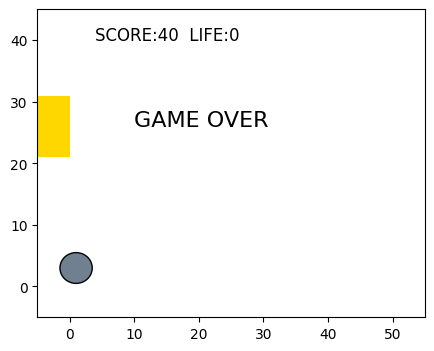

In [6]:
learner2 = PongAgent(game, policy=learner.get_policy())
learner2.ratio_explotacion = 1.0  # con esto quitamos las elecciones aleatorias al jugar
player = play(rounds=1, learner=learner2, game=game, animate=True)

#Desafio

Prueba con diferentes cantidades de epoca así como con más o menos vidas. Elabora cuando hay mejor rendimiento, puedes usar las funciones de tiempo que se vieron en prácticas pasadas del laboratorio

In [7]:
import time
import pandas as pd

# Comparamos distintas cantidades de épocas y de vidas.
# Se fija la semilla para que la comparación sea más reproducible.
np.random.seed(42)

configuraciones = [
    (300, 1),
    (300, 3),
    (300, 5),
    (800, 1),
    (800, 3),
    (800, 5)
]

resultados = []

for epocas, vidas in configuraciones:
    inicio = time.perf_counter()

    agente_entrenado, ambiente = play(
        rounds=epocas,
        max_life=vidas,
        discount_factor=0.2,
        learning_rate=0.1,
        ratio_explotacion=0.85,
        animate=False
    )

    tiempo_entrenamiento = time.perf_counter() - inicio

    # Evaluación: el agente deja de explorar y utiliza únicamente
    # la mejor acción conocida en su tabla Q.
    agente_evaluacion = PongAgent(ambiente, policy=agente_entrenado.get_policy())
    agente_evaluacion.ratio_explotacion = 1.0

    recompensas = []
    pasos = []

    for _ in range(20):
        estado = ambiente.reset()
        terminado = False
        n_pasos = 0

        while (not terminado) and (n_pasos < 3000) and (ambiente.total_reward <= 1000):
            accion = agente_evaluacion.get_next_step(estado, ambiente)
            estado, recompensa, terminado = ambiente.step(accion, animate=False)
            n_pasos += 1

        recompensas.append(ambiente.total_reward)
        pasos.append(n_pasos)

    resultados.append({
        'Epocas': epocas,
        'Vidas': vidas,
        'Tiempo_entrenamiento_s': round(tiempo_entrenamiento, 3),
        'Recompensa_promedio': round(float(np.mean(recompensas)), 2),
        'Recompensa_maxima': int(np.max(recompensas)),
        'Pasos_promedio': round(float(np.mean(pasos)), 2)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados


Begin new Train!
Partidas[ 299 ] Avg.Puntos[ -3 ] Max score[ 60 ] en partida[ 59 ]
Begin new Train!
Partidas[ 299 ] Avg.Puntos[ 11 ] Max score[ 110 ] en partida[ 171 ]
Begin new Train!
Partidas[ 299 ] Avg.Puntos[ 15 ] Max score[ 150 ] en partida[ 199 ]
Begin new Train!
-- Partidas[ 500 ] Avg.Puntos[ -2 ]  AVG Steps[ 46 ] Max Score[ 60 ]
Partidas[ 799 ] Avg.Puntos[ -2 ] Max score[ 110 ] en partida[ 597 ]
Begin new Train!
-- Partidas[ 500 ] Avg.Puntos[ 17 ]  AVG Steps[ 229 ] Max Score[ 160 ]
Partidas[ 799 ] Avg.Puntos[ 21 ] Max score[ 180 ] en partida[ 642 ]
Begin new Train!
-- Partidas[ 500 ] Avg.Puntos[ 24 ]  AVG Steps[ 371 ] Max Score[ 210 ]
Partidas[ 799 ] Avg.Puntos[ 34 ] Max score[ 260 ] en partida[ 708 ]


,Epocas,Vidas,Tiempo_entrenamiento_s,Recompensa_promedio,Recompensa_maxima,Pasos_promedio
0,300,1,0.701,-4.5,30,40.65
1,300,3,2.633,52.5,130,349.10
2,300,5,4.620,55.5,120,469.00
3,800,1,1.892,4.0,60,69.60
4,800,3,8.216,39.5,150,303.75
5,800,5,13.126,259.0,940,1102.95


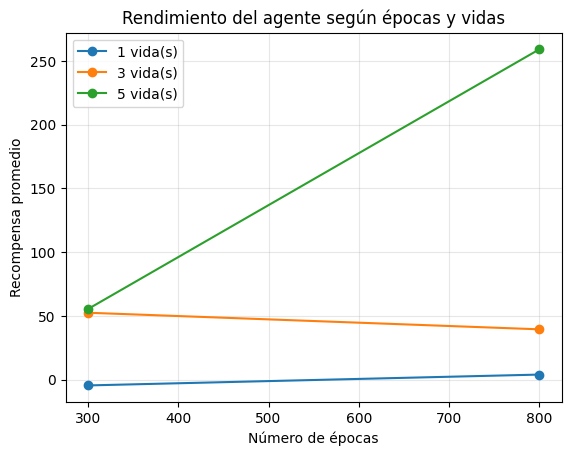

In [8]:
# Visualización del rendimiento obtenido
for vidas in sorted(df_resultados['Vidas'].unique()):
    datos = df_resultados[df_resultados['Vidas'] == vidas]
    plt.plot(datos['Epocas'], datos['Recompensa_promedio'], marker='o', label=f'{vidas} vida(s)')

plt.xlabel('Número de épocas')
plt.ylabel('Recompensa promedio')
plt.title('Rendimiento del agente según épocas y vidas')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Interpretación del desafío

El experimento compara el desempeño del agente modificando dos parámetros: el número de **épocas de entrenamiento** y la cantidad de **vidas disponibles**. La recompensa promedio permite observar qué tan bien logra devolver la pelota después del entrenamiento, mientras que el tiempo de ejecución muestra el costo computacional de entrenar durante más partidas.

En general, al aumentar el número de épocas el agente dispone de más oportunidades para actualizar su tabla Q y aprender qué acciones producen mejores recompensas. Sin embargo, esto también incrementa el tiempo de entrenamiento. Al aumentar el número de vidas, cada episodio puede durar más y el agente obtiene más experiencias antes de terminar la partida, por lo que también suele aumentar el número de pasos ejecutados.

Por lo tanto, el mejor rendimiento no debe interpretarse únicamente como el valor máximo de recompensa, sino como un equilibrio entre **recompensa obtenida, estabilidad del comportamiento y tiempo de entrenamiento**.

#Conclusiones finales del estudiante

En esta práctica se implementó un agente de **aprendizaje por refuerzo** para jugar una versión simplificada de Pong. El agente aprende mediante una **tabla Q**, en la que almacena el valor esperado de ejecutar cada acción en un estado determinado. Durante el entrenamiento se utiliza una estrategia de exploración-explotación: algunas veces el agente prueba acciones y otras selecciona la acción que hasta ese momento tiene el mayor valor en la tabla.

La actualización de los valores Q depende de la recompensa inmediata, del factor de descuento y de la mejor recompensa futura estimada. De esta manera, después de repetir muchas partidas, el agente puede favorecer acciones que aumenten la probabilidad de interceptar la pelota.

Al comparar diferentes números de épocas y vidas se observa que entrenar durante más partidas proporciona más experiencia al agente, aunque también aumenta el tiempo de ejecución. Asimismo, disponer de más vidas permite que cada episodio tenga una mayor duración y genere más transiciones de estado. Esto muestra que el desempeño del aprendizaje por refuerzo depende tanto de la cantidad de experiencia como de los hiperparámetros utilizados.

La práctica permite comprender de forma visual la idea central del aprendizaje por refuerzo: un agente mejora su comportamiento a partir de la interacción con un ambiente y de las recompensas que recibe, sin necesidad de que se le indique directamente cuál es la acción correcta en cada situación.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>